# Diagnosing illicit Bitcoin transaction detection with TARD

Graph models are useful for anti-money-laundering because suspicious transactions do not occur in isolation. But neighbourhood aggregation can also alter the distinctive transaction patterns that make unusual activity recognisable. Here we use TARD to inspect where those relationships change in a real Bitcoin transaction graph.

> When a graph model misses an illicit transaction, did neighbourhood aggregation substantially alter the transaction's original attribute relationships?

```text
transaction attributes  +  payment network
                    ↓
                   GCN
                    ↓
        illicit-transaction probability
                    +
                  TARD
                    ↓
    which relationships changed, and at which graph distance?
```

Data: Weber et al., *Anti-Money Laundering in Bitcoin: Experimenting with Graph Convolutional Networks for Financial Forensics*, KDD Workshop on Anomaly Detection in Finance, 2019.

In [1]:
import warnings

warnings.filterwarnings("ignore", message=".*torch.jit.script.*", category=FutureWarning)

In [2]:
%config InlineBackend.figure_formats = ["retina"]

from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from matplotlib.colors import ListedColormap
from scipy.stats import mannwhitneyu
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from torch import nn
from torch_geometric.datasets import EllipticBitcoinDataset
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected

import tard
from tard.metrics import cosine_similarity, hop_shells
from tard.result import DistortionResult

plt.rcParams.update(tard.visualization.STYLE)

DATA_ROOT = Path("../data/elliptic")
SEED = 0
LOCAL_FEATURES = 93
HIDDEN_DIMENSIONS = 32
EPOCHS = 200
LEARNING_RATE = 0.01
WEIGHT_DECAY = 5e-4
DROPOUT = 0.5
DECISION_THRESHOLD = 0.5
MAX_HOPS = 3
MIN_ILLICIT, MIN_LICIT = 20, 100

LICIT, ILLICIT, UNKNOWN = 0, 1, 2
CLASS_NAMES = {LICIT: "licit", ILLICIT: "illicit", UNKNOWN: "unknown"}
CLASS_COLORS = {LICIT: "#7f97b2", ILLICIT: "#d0632a", UNKNOWN: "#dcdbd6"}
OUTCOME_COLORS = {"detected": "#9a9892", "missed": "#d0632a"}
MODEL_COLORS = {"MLP": "#a9a7a1", "GCN": "#256abf"}
ATTRIBUTE_COLOR = "#1f1f1e"
INK, MUTED_INK, RULE = "#1f1f1e", "#6b6b68", "#d9d8d4"

torch.use_deterministic_algorithms(True)

## 1. Load the Elliptic graph

PyTorch Geometric downloads the data into `data/elliptic/` on first use (about 700 MB, not tracked by Git).

The raw file has one row per transaction: its ID, its time step, then 165 features. The dataset paper describes these as 94 *local* features (the time step and 93 transaction attributes such as fees, input and output counts and volumes) followed by 72 features *aggregated* from one-hop neighbouring transactions. PyG drops the ID and time step, so the local transaction attributes should be the first 93 columns of `data.x`. We check this against the raw file rather than assume it, and recover the time step, which PyG uses for its split but does not return.

In [3]:
dataset = EllipticBitcoinDataset(DATA_ROOT)
data = dataset[0]
raw_features = pd.read_csv(DATA_ROOT / "raw" / "elliptic_txs_features.csv", header=None)
time_step = raw_features[1].to_numpy()
labels = data.y.numpy()

layout_checks = {
    "raw file: ID + time step + 93 local + 72 aggregated columns": raw_features.shape[1]
    == 2 + LOCAL_FEATURES + 72,
    "data.x is exactly raw columns 3–167, in raw row order": np.allclose(
        raw_features.iloc[:, 2:].to_numpy(dtype=np.float32), data.x.numpy()
    ),
    "raw column 2 is an integer time step 1–49": set(np.unique(time_step)) == set(range(1, 50)),
    "raw time step reproduces PyG's train mask (steps 1–34)": np.array_equal(
        (time_step < 35) & (labels != UNKNOWN), data.train_mask.numpy()
    ),
    "raw time step reproduces PyG's test mask (steps 35–49)": np.array_equal(
        (time_step >= 35) & (labels != UNKNOWN), data.test_mask.numpy()
    ),
}
del raw_features
assert all(layout_checks.values())
pd.Series(layout_checks, name="verified")

raw file: ID + time step + 93 local + 72 aggregated columns    True
data.x is exactly raw columns 3–167, in raw row order          True
raw column 2 is an integer time step 1–49                      True
raw time step reproduces PyG's train mask (steps 1–34)         True
raw time step reproduces PyG's test mask (steps 35–49)         True
Name: verified, dtype: bool

In [4]:
train_mask = data.train_mask
test_mask = data.test_mask

pd.Series(
    {
        "transactions": data.num_nodes,
        "payment edges": data.num_edges,
        "labelled illicit": int((labels == ILLICIT).sum()),
        "labelled licit": int((labels == LICIT).sum()),
        "unknown": int((labels == UNKNOWN).sum()),
        "local feature dimensions": LOCAL_FEATURES,
        "train: time steps": f"1–34  ({int(train_mask.sum())} labelled)",
        "test: time steps": f"35–49  ({int(test_mask.sum())} labelled)",
    },
    name="Elliptic",
).to_frame()

,Elliptic
transactions,203769
payment edges,234355
labelled illicit,4545
labelled licit,42019
unknown,157205
local feature dimensions,93
train: time steps,1–34 (29894 labelled)
test: time steps,35–49 (16670 labelled)


The test transactions all occur later in time than the training transactions, so the models are evaluated on a future period they have not seen.

**Attributes.** We use only intrinsic, local transaction attributes, so that the reference space does not already encode the graph neighbourhood that TARD is intended to analyse. The 72 precomputed neighbourhood aggregates are discarded. The same 93 columns, standardised with training-node statistics only, are the input to both models and the reference attribute matrix $X$ for TARD.

**Topology.** The current case study treats payment connectivity as undirected when defining topological distance. Flow direction is intentionally left for future extensions. The same undirected edges are used for GCN message passing and for TARD's hop distances.

**Unknown labels.** Unlabelled transactions stay in the graph and pass messages, but never enter the loss or the metrics.

In [5]:
local_attributes = data.x[:, :LOCAL_FEATURES]
train_mean = local_attributes[train_mask].mean(dim=0)
train_std = local_attributes[train_mask].std(dim=0).clamp_min(1e-8)
features = (local_attributes - train_mean) / train_std
edge_index = to_undirected(data.edge_index)
targets = data.y

unknown_in_graph = np.isin(np.flatnonzero(labels == UNKNOWN), edge_index.numpy()).mean()
assert not (train_mask | test_mask)[targets == UNKNOWN].any()
pd.Series(
    {
        "model input dimensions": features.shape[1],
        "undirected edges (both directions)": edge_index.shape[1],
        "unknown nodes in supervised loss or metrics": int(
            (train_mask | test_mask)[targets == UNKNOWN].sum()
        ),
        "unknown nodes that take part in message passing": f"{unknown_in_graph:.0%}",
    },
    name="value",
).to_frame()

,value
model input dimensions,93
undirected edges (both directions),468710
unknown nodes in supervised loss or metrics,0
unknown nodes that take part in message passing,100%


## 2. Train a feature-only MLP and a GCN

Two deliberately ordinary models with the same input, the same 32-dimensional hidden layer, the same optimiser, the same number of epochs and the same seed:

- **MLP**: `93 → 32 → 2`. Uses only the transaction's own attributes. It establishes what can be learned without graph topology.
- **GCN**: two graph convolutions, `93 → 32 → 2`. Transforms the same attributes while aggregating neighbouring transactions.

The feature-only MLP provides a useful control for representation changes that do not arise from explicit graph message passing. For each model, the 32-dimensional hidden representation before the final layer is the representation $Z$ analysed by TARD.

In [6]:
class FeatureMLP(nn.Module):
    def __init__(self, input_dimensions, hidden_dimensions):
        super().__init__()
        self.encoder = nn.Linear(input_dimensions, hidden_dimensions)
        self.classifier = nn.Linear(hidden_dimensions, 2)

    def hidden(self, features, edge_index):
        return torch.relu(self.encoder(features))

    def forward(self, features, edge_index):
        hidden = F.dropout(self.hidden(features, edge_index), DROPOUT, self.training)
        return self.classifier(hidden)


class GCN(nn.Module):
    def __init__(self, input_dimensions, hidden_dimensions):
        super().__init__()
        self.encoder = GCNConv(input_dimensions, hidden_dimensions)
        self.classifier = GCNConv(hidden_dimensions, 2)

    def hidden(self, features, edge_index):
        return torch.relu(self.encoder(features, edge_index))

    def forward(self, features, edge_index):
        hidden = F.dropout(self.hidden(features, edge_index), DROPOUT, self.training)
        return self.classifier(hidden, edge_index)


def train(model_class):
    torch.manual_seed(SEED)
    model = model_class(LOCAL_FEATURES, HIDDEN_DIMENSIONS)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    for _ in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        logits = model(features, edge_index)
        F.cross_entropy(logits[train_mask], targets[train_mask]).backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        probability = model(features, edge_index).softmax(dim=1)[:, ILLICIT].numpy()
        hidden = model.hidden(features, edge_index).numpy()
    return probability, hidden


illicit_probability, hidden_representation = {}, {}
for name, model_class in {"MLP": FeatureMLP, "GCN": GCN}.items():
    illicit_probability[name], hidden_representation[name] = train(model_class)

{name: hidden.shape for name, hidden in hidden_representation.items()}

{'MLP': (203769, 32), 'GCN': (203769, 32)}

## 3. Standard metrics tell one story

Illicit transactions are about 10 % of the labelled transactions, so accuracy is not informative. We report precision, recall and F1 for the illicit class at a 0.5 threshold, and the threshold-free area under the precision–recall curve, all on the same held-out test transactions.

In [7]:
test_labels = labels[test_mask.numpy()]


def illicit_metrics(probability):
    scores = probability[test_mask.numpy()]
    predicted = (scores >= DECISION_THRESHOLD).astype(int)
    return {
        "precision": precision_score(test_labels, predicted),
        "recall": recall_score(test_labels, predicted),
        "F1": f1_score(test_labels, predicted),
        "PR-AUC": average_precision_score(test_labels, scores),
    }


classification = pd.DataFrame(
    {name: illicit_metrics(probability) for name, probability in illicit_probability.items()}
).T
classification.round(3)

,precision,recall,F1,PR-AUC
MLP,0.860,0.684,0.762,0.693
GCN,0.552,0.538,0.545,0.529


On this temporal split the feature-only MLP has higher illicit precision, recall, F1 and PR-AUC than the GCN (F1 0.76 vs 0.55). Weber et al. similarly report that a feature-based random forest outperforms their GCN. This describes these two small models on this split, not graph models in general.

These metrics tell us how successfully each representation supports illicit-transaction classification. They do not tell us how graph representation learning changed the transaction relationships that produced those predictions.

## 4. Select one held-out transaction graph

Detailed analysis uses one held-out time step. It is chosen by a rule fixed in advance that looks only at label counts, never at model output: **the earliest test time step with at least 20 labelled illicit and 100 labelled licit transactions.** Payment edges in Elliptic never cross time steps, so a time step is a self-contained transaction graph. We keep its largest connected component, including all unlabelled transactions.

In [8]:
def select_analysis_time_step(min_illicit, min_licit):
    for step in range(35, 50):
        step_labels = labels[time_step == step]
        if (step_labels == ILLICIT).sum() >= min_illicit and (
            step_labels == LICIT
        ).sum() >= min_licit:
            return step
    raise ValueError("no test time step meets the label-count rule")


def time_step_graph(step):
    step_nodes = np.flatnonzero(time_step == step)
    source, target = edge_index.numpy()
    inside = np.isin(source, step_nodes) & np.isin(target, step_nodes)
    graph = nx.Graph()
    graph.add_nodes_from(step_nodes.tolist())
    graph.add_edges_from(zip(source[inside].tolist(), target[inside].tolist(), strict=True))
    return graph


analysis_step = select_analysis_time_step(MIN_ILLICIT, MIN_LICIT)
step_graph = time_step_graph(analysis_step)
largest_component = max(nx.connected_components(step_graph), key=len)
analysis_graph = step_graph.subgraph(sorted(largest_component)).copy()
analysis_nodes = list(analysis_graph.nodes)
analysis_labels = pd.Series(labels[analysis_nodes], index=analysis_nodes)

pd.Series(
    {
        "time step": analysis_step,
        "transactions in time step": step_graph.number_of_nodes(),
        "transactions in largest component": analysis_graph.number_of_nodes(),
        "payment edges": analysis_graph.number_of_edges(),
        "labelled illicit": int((analysis_labels == ILLICIT).sum()),
        "labelled licit": int((analysis_labels == LICIT).sum()),
        "unknown": int((analysis_labels == UNKNOWN).sum()),
    },
    name="analysis graph",
).to_frame()

,analysis graph
time step,35
transactions in time step,5507
transactions in largest component,5507
payment edges,6351
labelled illicit,182
labelled licit,1159
unknown,4166


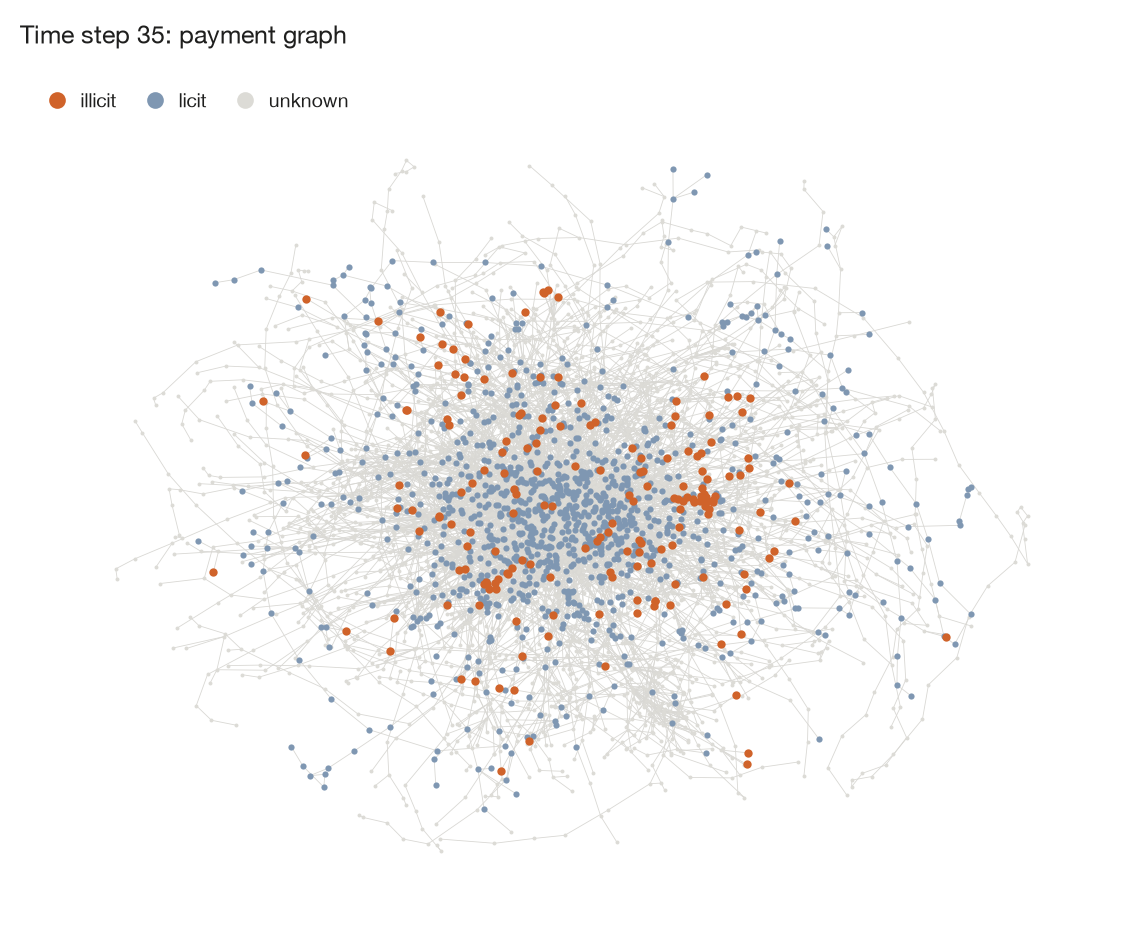

In [9]:
def legend_marker(color, label, size=5):
    return plt.Line2D([], [], marker="o", linestyle="", markersize=size, color=color, label=label)


overview_positions = nx.spring_layout(analysis_graph, seed=SEED, iterations=50)

fig, ax = plt.subplots(figsize=(5.6, 4.6), layout="constrained")
nx.draw_networkx_edges(analysis_graph, overview_positions, ax=ax, edge_color=RULE, width=0.3)
for label, size in [(UNKNOWN, 2), (LICIT, 5), (ILLICIT, 9)]:
    nx.draw_networkx_nodes(
        analysis_graph,
        overview_positions,
        nodelist=list(analysis_labels.index[analysis_labels == label]),
        node_color=CLASS_COLORS[label],
        node_size=size,
        linewidths=0,
        ax=ax,
    )
ax.legend(
    handles=[
        legend_marker(CLASS_COLORS[label], CLASS_NAMES[label])
        for label in (ILLICIT, LICIT, UNKNOWN)
    ],
    frameon=False,
    loc="upper left",
    ncols=3,
    bbox_to_anchor=(0.0, 1.02),
    handletextpad=0.2,
    columnspacing=1.0,
)
ax.set_title(f"Time step {analysis_step}: payment graph", loc="left", pad=16)
ax.set_axis_off()

## 5. Compare relational distortion

TARD compares, for every transaction and each hop distance $k = 1, 2, 3$, its cosine similarity to the transactions exactly $k$ hops away in the attribute space $X$ and in the hidden representation $Z$. It uses no labels. Both representations are analysed on exactly the same nodes and the same topology.

In [10]:
analysis_attributes = pd.DataFrame(features[analysis_nodes].numpy(), index=analysis_nodes)
analysis_embeddings = {
    name: pd.DataFrame(hidden[analysis_nodes], index=analysis_nodes)
    for name, hidden in hidden_representation.items()
}

tard_results = {
    name: tard.compute(
        graph=analysis_graph,
        attributes=analysis_attributes,
        embeddings=embeddings,
        max_hops=MAX_HOPS,
    )
    for name, embeddings in analysis_embeddings.items()
}
assert tard_results["MLP"].nodes == tard_results["GCN"].nodes == analysis_nodes

pd.Series(
    {name: result.global_distortion for name, result in tard_results.items()},
    name="global distortion",
).to_frame().round(3)

,global distortion
MLP,0.229
GCN,0.351


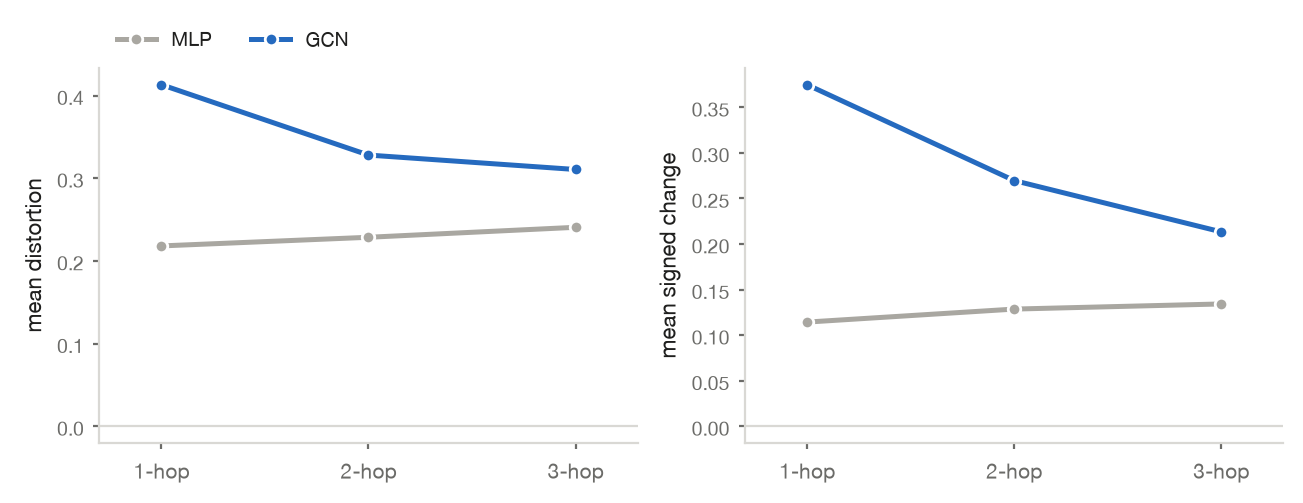

In [11]:
def style_axis(ax):
    ax.tick_params(length=2)
    ax.spines[["top", "right"]].set_visible(False)


def plot_scale_profiles(ax, profiles, ylabel, colors, **line_style):
    ax.axhline(0, color=RULE, linewidth=0.8, zorder=0)
    for name, profile in profiles.items():
        ax.plot(
            range(1, len(profile) + 1),
            np.asarray(profile, dtype=float),
            color=colors[name],
            marker="o",
            markersize=4.5,
            markeredgecolor="white",
            linewidth=1.8,
            label=name,
            **line_style,
        )
    ax.set_xticks(range(1, MAX_HOPS + 1), [f"{hop}-hop" for hop in range(1, MAX_HOPS + 1)])
    ax.set_xlim(0.7, MAX_HOPS + 0.3)
    ax.set_ylabel(ylabel)
    style_axis(ax)


fig, (left, right) = plt.subplots(1, 2, figsize=(6.4, 2.4), layout="constrained")
plot_scale_profiles(
    left,
    {name: result.distortion.mean() for name, result in tard_results.items()},
    "mean distortion",
    MODEL_COLORS,
)
plot_scale_profiles(
    right,
    {name: result.signed_change.mean() for name, result in tard_results.items()},
    "mean signed change",
    MODEL_COLORS,
)
left.legend(frameon=False, loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=2);

Both representations change relationships at every scale, and part of the change is shared. Hidden ReLU units are non-negative, so pairs with a negative cosine similarity in the standardised attributes cannot keep it in either $Z$. This is why the MLP's signed change is positive (0.11–0.13) and nearly flat across scales.

The GCN departs from this control mainly at short range. Its mean 1-hop distortion is 0.41 against 0.22 for the MLP, and its signed change falls from 0.37 at 1 hop to 0.21 at 3 hops. Message passing makes directly connected transactions markedly more similar, with an effect that decreases with graph distance. The global scores (0.35 vs 0.23) summarise this difference but hide its dependence on scale.

## 6. Focus on illicit transactions

From here on, labels are used, but only to *interpret* the label-free distortion values. For every labelled illicit transaction in the analysis graph we collect the GCN's illicit probability, whether it was detected at the 0.5 threshold, and its GCN distortion and signed change at each scale. As context we add the **licit-neighbour fraction**: the fraction of its labelled direct neighbours that are licit (undefined when no direct neighbour is labelled).

In [12]:
gcn_result = tard_results["GCN"]
illicit_nodes = list(analysis_labels.index[analysis_labels == ILLICIT])


def licit_neighbor_fraction(node):
    labelled = [
        labels[neighbor] for neighbor in analysis_graph[node] if labels[neighbor] != UNKNOWN
    ]
    return np.mean([label == LICIT for label in labelled]) if labelled else np.nan


def outcome(probability):
    return np.where(probability >= DECISION_THRESHOLD, "detected", "missed")


illicit_diagnostics = pd.DataFrame(
    {
        "GCN probability": illicit_probability["GCN"][illicit_nodes],
        "outcome": outcome(illicit_probability["GCN"][illicit_nodes]),
        **gcn_result.distortion.loc[illicit_nodes].add_suffix(" distortion"),
        **gcn_result.signed_change.loc[illicit_nodes].add_suffix(" signed change"),
        "licit-neighbour fraction": [licit_neighbor_fraction(node) for node in illicit_nodes],
        "degree": [analysis_graph.degree[node] for node in illicit_nodes],
    },
    index=pd.Index(illicit_nodes, name="node"),
)
print(illicit_diagnostics["outcome"].value_counts().to_string())
illicit_diagnostics.sort_values("GCN probability").head(8).round(3)

outcome
detected    129
missed       53


,GCN probability,outcome,1-hop distortion,2-hop distortion,3-hop distortion,1-hop signed change,2-hop signed change,3-hop signed change,licit-neighbour fraction,degree
node,,,,,,,,,,
136312,0.007,missed,0.581,0.547,0.484,0.581,0.530,0.468,1.000,48
140592,0.048,missed,0.412,0.376,0.330,0.412,0.376,0.330,1.000,1
140961,0.072,missed,0.504,0.213,0.368,0.504,0.213,0.304,1.000,1
138377,0.074,missed,0.801,0.831,0.261,0.375,-0.601,-0.255,1.000,2
139690,0.086,missed,1.054,0.639,0.339,1.054,0.575,0.104,1.000,1
138024,0.105,missed,0.495,0.261,0.382,0.209,-0.080,-0.230,1.000,2
137950,0.112,missed,0.373,0.212,0.254,0.275,0.116,0.074,0.333,5
138156,0.120,missed,0.005,0.430,0.306,-0.005,0.420,0.288,0.000,1


## 7. Do missed illicit transactions look different?

We first test the question stated at the outset, whether missed illicit transactions show stronger **1-hop** distortion, and then look at the same comparison at 2 and 3 hops. Each panel shows every transaction as a dot, with the median and interquartile range.

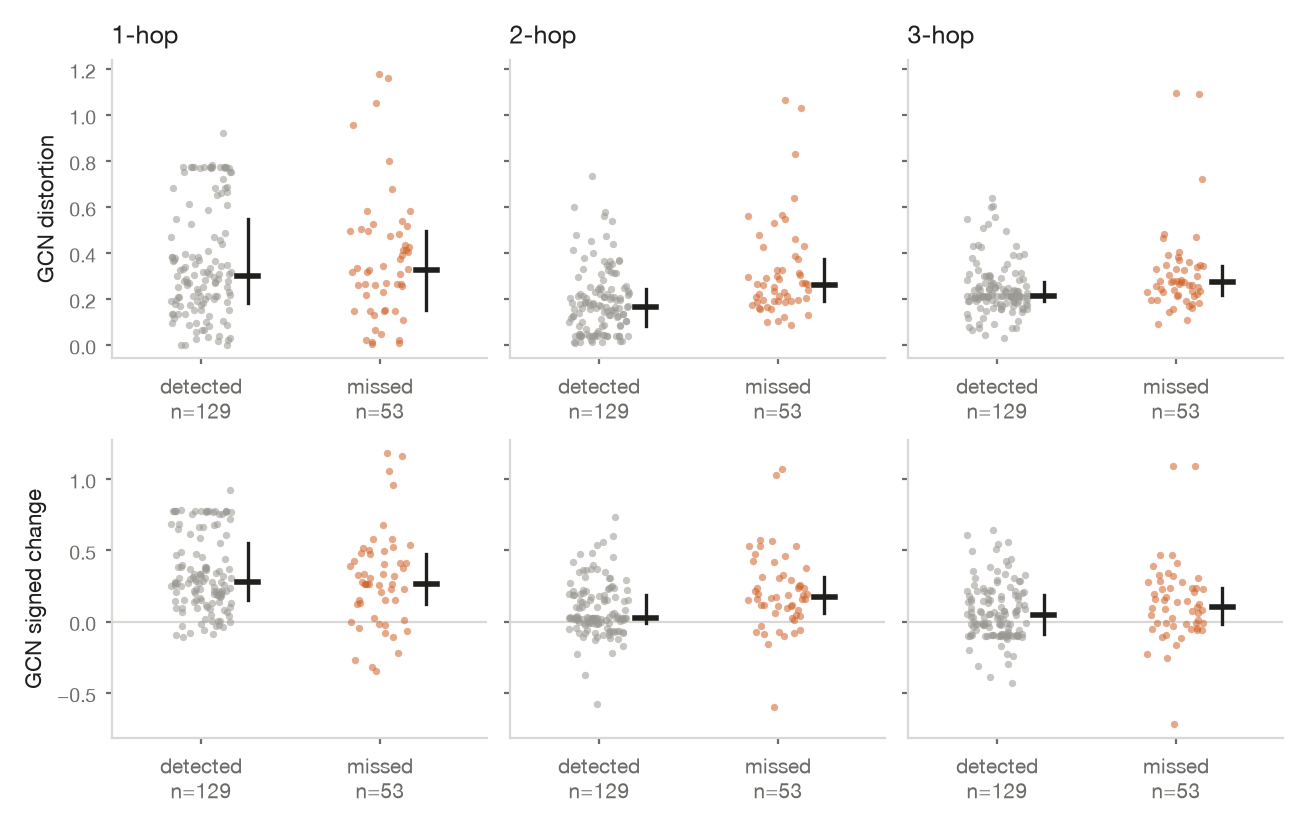

In [13]:
def plot_outcome_distributions(ax, values_by_outcome, rng):
    for position, (name, values) in enumerate(values_by_outcome.items()):
        values = values.dropna().to_numpy()
        jitter = rng.uniform(-0.17, 0.17, len(values))
        ax.scatter(
            position + jitter,
            values,
            s=7,
            color=OUTCOME_COLORS[name],
            alpha=0.55,
            linewidths=0,
        )
        lower, median, upper = np.percentile(values, [25, 50, 75])
        ax.plot([position + 0.26] * 2, [lower, upper], color=INK, linewidth=1.2)
        ax.plot([position + 0.2, position + 0.32], [median] * 2, color=INK, linewidth=2)
    ax.set_xticks(
        range(len(values_by_outcome)),
        [f"{name}\nn={len(v)}" for name, v in values_by_outcome.items()],
    )
    ax.set_xlim(-0.5, len(values_by_outcome) - 0.4)
    style_axis(ax)


groups = dict(tuple(illicit_diagnostics.groupby("outcome")))
fig, axes = plt.subplots(2, MAX_HOPS, figsize=(6.4, 4.0), layout="constrained", sharey="row")
jitter_rng = np.random.default_rng(SEED)
for column, scale in enumerate(gcn_result.distortion.columns):
    for row, quantity in enumerate(["distortion", "signed change"]):
        ax = axes[row, column]
        if quantity == "signed change":
            ax.axhline(0, color=RULE, linewidth=0.8, zorder=0)
        plot_outcome_distributions(
            ax,
            {name: groups[name][f"{scale} {quantity}"] for name in ("detected", "missed")},
            jitter_rng,
        )
        if row == 0:
            ax.set_title(scale, loc="left")
        if column == 0:
            ax.set_ylabel(f"GCN {quantity}")

As a transparent effect size we report, for each scale, the probability that a randomly chosen missed transaction has a larger value than a randomly chosen detected one (0.5 means no difference), with a two-sided Mann–Whitney $p$-value. The 1-hop comparison is the one stated in advance; the 2- and 3-hop comparisons are exploratory.

In [14]:
def compare_outcomes(column):
    detected = groups["detected"][column].dropna()
    missed = groups["missed"][column].dropna()
    test = mannwhitneyu(missed, detected, alternative="two-sided")
    return {
        "median detected": detected.median(),
        "median missed": missed.median(),
        "P(missed > detected)": test.statistic / (len(missed) * len(detected)),
        "p-value": test.pvalue,
    }


outcome_comparison = pd.DataFrame(
    {
        f"{scale} {quantity}": compare_outcomes(f"{scale} {quantity}")
        for quantity in ["distortion", "signed change"]
        for scale in gcn_result.distortion.columns
    }
).T
outcome_comparison.round(
    {"median detected": 3, "median missed": 3, "P(missed > detected)": 2, "p-value": 7}
)

,median detected,median missed,P(missed > detected),p-value
1-hop distortion,0.300,0.325,0.51,0.789980
2-hop distortion,0.165,0.261,0.72,0.000002
3-hop distortion,0.215,0.275,0.65,0.001856
1-hop signed change,0.280,0.267,0.47,0.476282
2-hop signed change,0.025,0.173,0.66,0.000587
3-hop signed change,0.046,0.104,0.59,0.066286


In [15]:
licit_context = illicit_diagnostics.groupby("outcome")["licit-neighbour fraction"].agg(
    ["count", "mean"]
)
licit_context.rename(columns={"count": "with labelled neighbours"}).round(2)

,with labelled neighbours,mean
outcome,,
detected,41,0.51
missed,35,0.75


**Are false negatives associated with stronger 1-hop distortion?** No. Missed and detected illicit transactions have nearly the same 1-hop distortion (medians 0.33 and 0.30, $P = 0.51$, $p = 0.79$) and the same 1-hop signed change. The GCN makes almost every illicit transaction more similar to its direct neighbours, whether or not it is detected afterwards.

**Are they pulled towards greater neighbourhood similarity?** Not at 1 hop, but at 2 hops. Missed transactions have higher 2-hop distortion (median 0.26 vs 0.17, $P = 0.72$, $p = 2 \times 10^{-6}$) and a more positive 2-hop signed change (0.17 vs 0.03, $P = 0.66$): the GCN makes them more similar to transactions two payments away, while detected transactions largely keep their original 2-hop relationships. At 3 hops the difference points the same way but is smaller. Retraining both models with seeds 1–4 gave the same picture: $P$ between 0.45 and 0.51 at 1 hop, and between 0.65 and 0.72 at 2 hops.

Missed transactions also more often have licit direct neighbours (0.75 vs 0.51), but this rests on the 35 missed and 41 detected transactions that have any labelled neighbour, and it is context, not part of TARD.

## 8. The illicit-transaction distortion matrix

Every labelled illicit transaction in the analysis graph is a row; columns are the three scales; colour is GCN distortion. Rows are grouped into detected and missed transactions and, within each group, sorted from highest to lowest GCN illicit probability.

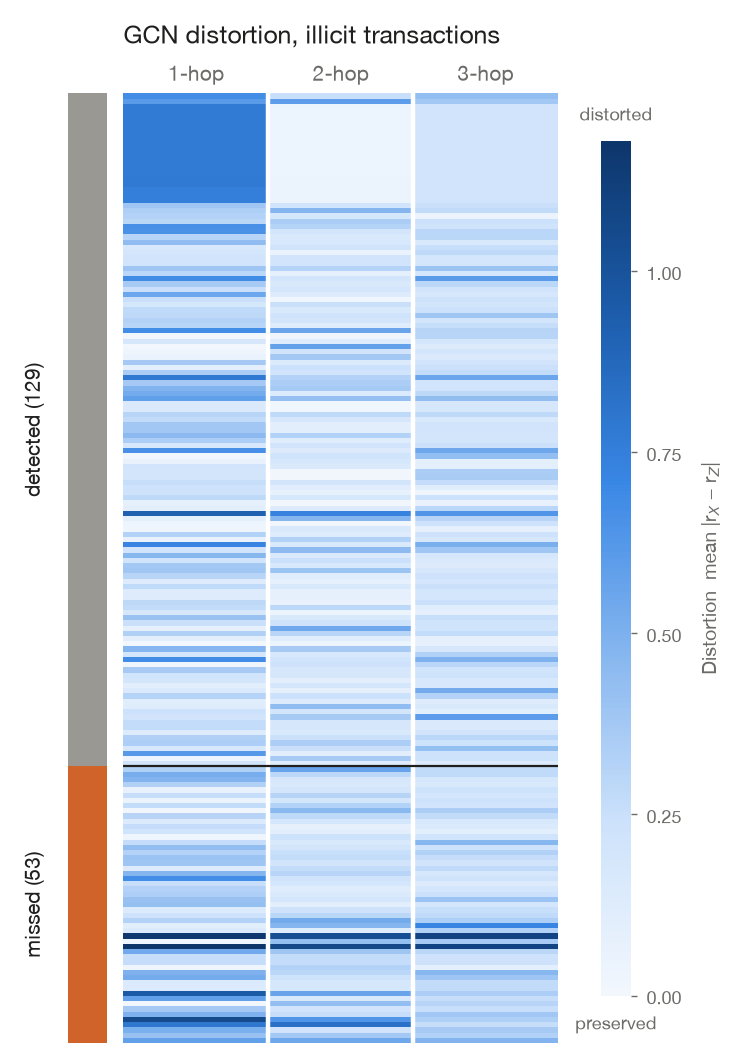

In [16]:
matrix_order = illicit_diagnostics.sort_values(
    ["outcome", "GCN probability"], ascending=[True, False]
).index
illicit_result = DistortionResult(
    distortion=gcn_result.distortion.loc[matrix_order],
    signed_change=gcn_result.signed_change.loc[matrix_order],
    nodes=list(matrix_order),
    scales=gcn_result.scales,
)
outcome_codes = (illicit_diagnostics.loc[matrix_order, "outcome"] == "missed").to_numpy(int)
boundary = int((outcome_codes == 0).sum())

fig, (strip_ax, matrix_ax) = plt.subplots(
    1, 2, figsize=(3.6, 5.2), layout="constrained", gridspec_kw={"width_ratios": [0.09, 1]}
)
tard.plot_distortion_map(illicit_result, ax=matrix_ax, title="GCN distortion, illicit transactions")
matrix_ax.set_ylabel("")
matrix_ax.axhline(boundary, color=INK, linewidth=0.8)
strip_ax.pcolormesh(
    outcome_codes[:, None],
    cmap=ListedColormap([OUTCOME_COLORS["detected"], OUTCOME_COLORS["missed"]]),
    vmin=0,
    vmax=1,
)
strip_ax.set_ylim(len(outcome_codes), 0)
strip_ax.set_axis_off()
for name, center in [("detected", boundary / 2), ("missed", (boundary + len(outcome_codes)) / 2)]:
    strip_ax.text(
        -0.6,
        center,
        f"{name} ({int((outcome_codes == (name == 'missed')).sum())})",
        rotation=90,
        ha="right",
        va="center",
        fontsize=7.5,
        color=INK,
    )

At 1 hop, missed transactions do not form a separate block: high and low 1-hop distortion occur in both groups. The difference appears in the 2- and 3-hop columns, which are light for most detected transactions and darker for many missed ones. The block at the top is a group of confidently detected transactions with similar 1-hop distortion (≈ 0.77) and almost unchanged 2-hop relationships. The darkest rows, with distortion above 1 at every scale, are all missed transactions.

## 9. An illustrative high-distortion false negative

Selection rule: **among the illicit transactions the GCN missed, take the one with the largest 1-hop GCN distortion.** This is an illustrative high-distortion false negative, chosen to show what TARD localises; it is not a representative transaction. The table lists the five missed transactions with the largest 1-hop distortion; the first is selected.

In [17]:
missed_nodes = illicit_diagnostics.index[illicit_diagnostics["outcome"] == "missed"]
missed_by_distortion = (
    illicit_diagnostics.loc[missed_nodes]
    .assign(**{"MLP probability": illicit_probability["MLP"][missed_nodes]})
    .sort_values("1-hop distortion", ascending=False)
)
focal_node = missed_by_distortion.index[0]
focal_shells = hop_shells(analysis_graph, focal_node, MAX_HOPS)

missed_by_distortion[
    [
        "GCN probability",
        "MLP probability",
        "1-hop distortion",
        "1-hop signed change",
        "2-hop distortion",
        "degree",
        "licit-neighbour fraction",
    ]
].head(5).round(3)

,GCN probability,MLP probability,1-hop distortion,1-hop signed change,2-hop distortion,degree,licit-neighbour fraction
node,,,,,,,
139715,0.271,0.753,1.180,1.180,1.068,1,1.0
136972,0.276,0.755,1.163,1.163,1.031,1,1.0
139690,0.086,0.751,1.054,1.054,0.639,1,1.0
139663,0.135,0.751,0.959,0.959,0.559,1,1.0
138377,0.074,0.750,0.801,0.375,0.831,2,1.0


## 10. Which relationships changed?

A shows the focal transaction's payment neighbourhood: every transaction within the three scales TARD analyses (fewer hops if that would exceed 30 transactions). B shows how similar each of them is to the focal transaction in the original attribute space. C shows the same transactions in the GCN representation, with the original value as a hollow marker; the connector's width and colour show the size and direction of the change (blue: more similar, red: less similar). Neighbours are in the same order in B and C.

,hop,label,original similarity,GCN similarity,MLP similarity,change
node,,,,,,
139391,1,licit,-0.241,0.939,0.026,1.180
137815,2,licit,-0.241,0.840,0.040,1.081
139390,2,licit,-0.242,0.813,0.024,1.055
137816,3,licit,-0.214,0.920,0.126,1.134
141379,3,licit,-0.242,0.815,0.025,1.056


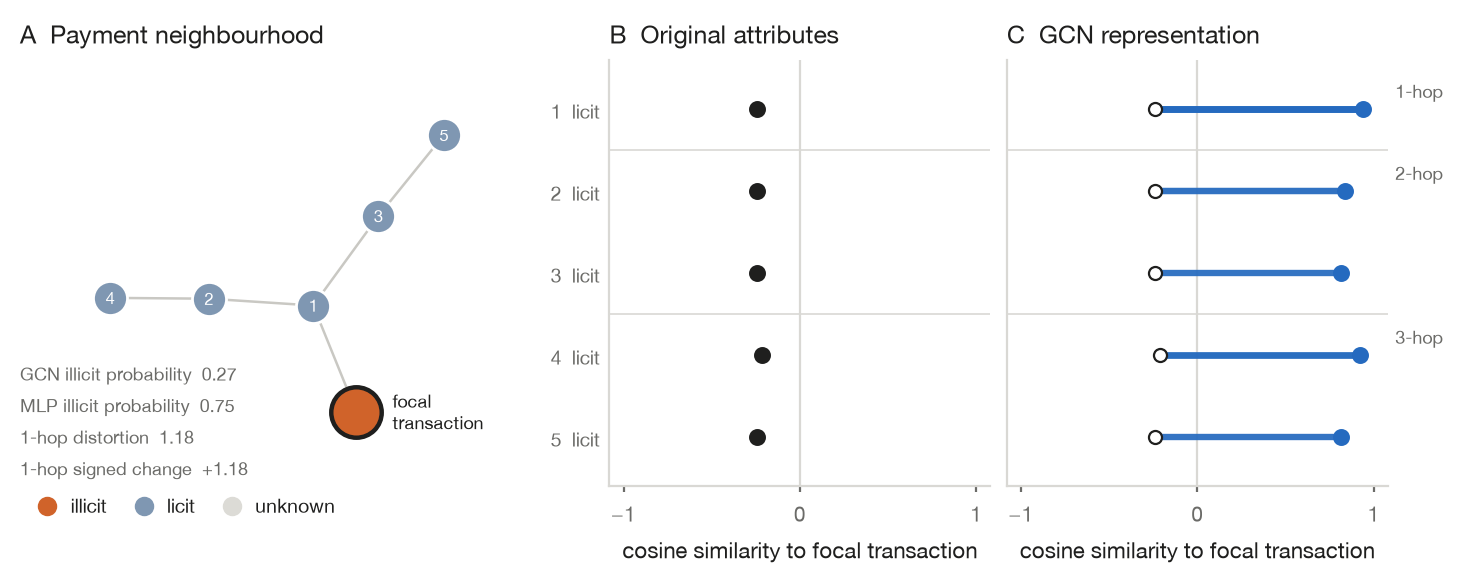

In [18]:
MAX_LOCAL_TRANSACTIONS = 30
local_hops = max(
    [1]
    + [
        hops
        for hops in range(1, MAX_HOPS + 1)
        if sum(len(focal_shells.get(hop, [])) for hop in range(1, hops + 1))
        <= MAX_LOCAL_TRANSACTIONS
    ]
)


def similarity_to_focal(representation, others):
    return cosine_similarity(
        representation.loc[focal_node].to_numpy(), representation.loc[others].to_numpy()
    )


local_rows = []
for hop in range(1, local_hops + 1):
    shell = focal_shells[hop]
    shell_table = pd.DataFrame(
        {
            "hop": hop,
            "label": [CLASS_NAMES[labels[node]] for node in shell],
            "original similarity": similarity_to_focal(analysis_attributes, shell),
            "GCN similarity": similarity_to_focal(analysis_embeddings["GCN"], shell),
            "MLP similarity": similarity_to_focal(analysis_embeddings["MLP"], shell),
        },
        index=pd.Index(shell, name="node"),
    )
    local_rows.append(shell_table.sort_values("original similarity", ascending=False))
local_table = pd.concat(local_rows)
local_table["change"] = local_table["GCN similarity"] - local_table["original similarity"]
local_table["key"] = [str(position) for position in range(1, len(local_table) + 1)]
largest_change = local_table["change"].abs().max()


def draw_neighborhood(ax):
    ego = analysis_graph.subgraph([focal_node, *local_table.index])
    positions = nx.kamada_kawai_layout(ego)
    nx.draw_networkx_edges(ego, positions, ax=ax, edge_color="#c9c8c3", width=0.9)
    for node in local_table.index:
        ax.scatter(
            *positions[node],
            s=150,
            color=CLASS_COLORS[labels[node]],
            edgecolors="white",
            linewidths=1.0,
            zorder=3,
        )
        ax.text(
            *positions[node],
            local_table.loc[node, "key"],
            ha="center",
            va="center",
            fontsize=6,
            color=INK if labels[node] == UNKNOWN else "white",
            zorder=4,
        )
    ax.scatter(
        *positions[focal_node],
        s=330,
        color=CLASS_COLORS[ILLICIT],
        edgecolors=INK,
        linewidths=1.6,
        zorder=3,
    )
    ax.annotate(
        "focal\ntransaction",
        positions[focal_node],
        xytext=(13, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=6.5,
        color=INK,
    )
    ax.margins(0.2)
    ax.set_axis_off()
    focal_summary = "\n".join(
        [
            f"GCN illicit probability  {illicit_probability['GCN'][focal_node]:.2f}",
            f"MLP illicit probability  {illicit_probability['MLP'][focal_node]:.2f}",
            f"1-hop distortion  {gcn_result.distortion.loc[focal_node, '1-hop']:.2f}",
            f"1-hop signed change  {gcn_result.signed_change.loc[focal_node, '1-hop']:+.2f}",
        ]
    )
    ax.text(
        0.0,
        0.0,
        focal_summary,
        transform=ax.transAxes,
        fontsize=6.5,
        color=MUTED_INK,
        va="bottom",
        linespacing=1.5,
    )
    ax.legend(
        handles=[
            legend_marker(CLASS_COLORS[label], CLASS_NAMES[label], 6)
            for label in (ILLICIT, LICIT, UNKNOWN)
        ],
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.0, 0.0),
        ncols=3,
        handletextpad=0.2,
        columnspacing=0.9,
        borderaxespad=0.0,
    )


def format_similarity_axis(ax, title, label_hops):
    rows = np.arange(len(local_table))
    ax.axvline(0, color=RULE, linewidth=0.8, zorder=0)
    ax.set_xlim(-1.08, 1.08)
    ax.set_xticks([-1, 0, 1])
    ax.set_ylim(len(local_table) - 0.4, -0.6)
    ax.set_yticks(
        rows,
        [
            f"{key}  {label}"
            for key, label in zip(local_table["key"], local_table["label"], strict=True)
        ],
    )
    ax.set_xlabel("cosine similarity to focal transaction")
    ax.set_title(title, loc="left")
    for hop, rows_in_hop in local_table.reset_index().groupby("hop").groups.items():
        if rows_in_hop.min() > 0:
            ax.axhline(rows_in_hop.min() - 0.5, color=RULE, linewidth=0.6)
        if not label_hops:
            continue
        ax.text(
            1.02,
            rows_in_hop.min() - 0.35,
            f"{hop}-hop",
            transform=ax.get_yaxis_transform(),
            fontsize=6.5,
            color=MUTED_INK,
            va="top",
        )
    style_axis(ax)
    ax.tick_params(axis="y", length=0)


rows = np.arange(len(local_table))
figure_height = max(2.8, 0.2 * len(local_table) + 1.3)
fig, (neighborhood_ax, original_ax, learned_ax) = plt.subplots(
    1,
    3,
    figsize=(7.2, figure_height),
    layout="constrained",
    gridspec_kw={"width_ratios": [1.35, 1, 1]},
)
draw_neighborhood(neighborhood_ax)
neighborhood_ax.set_title("A  Payment neighbourhood", loc="left")

original_ax.scatter(local_table["original similarity"], rows, s=26, color=ATTRIBUTE_COLOR, zorder=3)
format_similarity_axis(original_ax, "B  Original attributes", label_hops=False)

for row, node in enumerate(local_table.index):
    change = local_table.loc[node, "change"]
    learned_ax.plot(
        local_table.loc[node, ["original similarity", "GCN similarity"]],
        [row, row],
        color=MODEL_COLORS["GCN"] if change > 0 else "#d64545",
        linewidth=0.5 + 2.0 * abs(change) / largest_change,
        alpha=0.35 + 0.65 * abs(change) / largest_change,
        solid_capstyle="butt",
        zorder=2,
    )
learned_ax.scatter(
    local_table["original similarity"],
    rows,
    s=22,
    facecolors="white",
    edgecolors=ATTRIBUTE_COLOR,
    linewidths=0.8,
    zorder=3,
)
learned_ax.scatter(local_table["GCN similarity"], rows, s=26, color=MODEL_COLORS["GCN"], zorder=4)
format_similarity_axis(learned_ax, "C  GCN representation", label_hops=True)
learned_ax.set_yticklabels([])

local_table.drop(columns="key").round(3)

The transaction's neighbourhood within three hops consists of five licit transactions. In the original attribute space the focal transaction is dissimilar to all of them (cosine ≈ −0.24). In the GCN representation it is highly similar to all of them (0.81–0.94); the largest change is with its only direct counterparty (+1.18). The feature-only MLP keeps these similarities near zero (0.02–0.13) and gives the transaction an illicit probability of 0.75, against 0.27 for the GCN.

The false negative coincides with a substantial change in the focal transaction's local relational profile: the GCN representation moves the transaction close to its licit surroundings, which is consistent with its lower illicit score. This does not establish that the aggregation caused the miss. The table in section 9 shows that the next three missed transactions by 1-hop distortion share the same configuration: a single licit counterparty and an MLP probability of 0.75.

## 11. The topology–attribute relationship profile

For the same transaction: its mean similarity to the transactions exactly 1, 2 and 3 hops away, in the original attribute space and in each learned representation. The gap between the black and the blue profile at each scale is the signed change that TARD reports for this transaction; the grey MLP profile is the feature-only control.

,1-hop,2-hop,3-hop
original attributes,-0.241,-0.241,-0.228
MLP,0.026,0.032,0.075
GCN,0.939,0.826,0.868


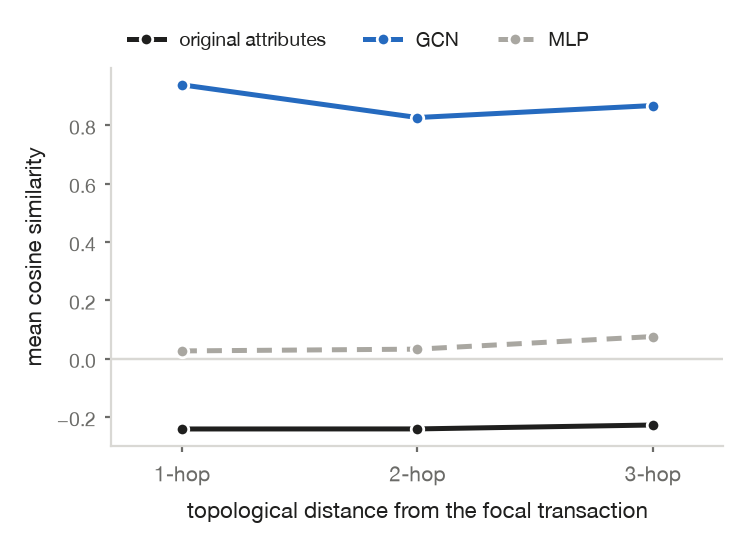

In [19]:
def similarity_profile(representation):
    return [
        similarity_to_focal(representation, focal_shells[hop]).mean()
        for hop in range(1, MAX_HOPS + 1)
    ]


profiles = {
    "original attributes": similarity_profile(analysis_attributes),
    "MLP": similarity_profile(analysis_embeddings["MLP"]),
    "GCN": similarity_profile(analysis_embeddings["GCN"]),
}
profile_colors = {"original attributes": ATTRIBUTE_COLOR, **MODEL_COLORS}

fig, ax = plt.subplots(figsize=(3.6, 2.6), layout="constrained")
plot_scale_profiles(
    ax, {"MLP": profiles["MLP"]}, "mean cosine similarity", profile_colors, linestyle=(0, (3, 2))
)
plot_scale_profiles(
    ax,
    {name: profiles[name] for name in ("original attributes", "GCN")},
    "mean cosine similarity",
    profile_colors,
)
ax.set_xlabel("topological distance from the focal transaction")
handles, names = ax.get_legend_handles_labels()
legend_order = [names.index(name) for name in ("original attributes", "GCN", "MLP")]
ax.legend(
    [handles[index] for index in legend_order],
    [names[index] for index in legend_order],
    frameon=False,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.0),
    ncols=3,
    handlelength=1.8,
)
pd.DataFrame(profiles, index=gcn_result.distortion.columns).T.round(3)

In the attributes, the profile is flat and negative: the transaction is equally unlike its surroundings at every distance. In the GCN representation it is flat and high: up to three hops, the transaction is now close to everything around it. The MLP moves the profile only to about zero, the ReLU effect seen in section 5. The change is therefore not confined to the direct counterparty; it spans the transaction's whole local neighbourhood.

## 12. Model-level comparison

In [20]:
def missed_mask(name):
    return illicit_probability[name][illicit_nodes] < DECISION_THRESHOLD


pd.DataFrame(
    {
        name: {
            "illicit F1 (all test steps)": classification.loc[name, "F1"],
            "illicit recall (all test steps)": classification.loc[name, "recall"],
            f"missed illicit, step {analysis_step}": int(missed_mask(name).sum()),
            "mean 1-hop distortion, all nodes": result.distortion["1-hop"].mean(),
            "mean 2-hop distortion, all nodes": result.distortion["2-hop"].mean(),
            "mean 2-hop distortion, missed illicit": result.distortion.loc[
                np.array(illicit_nodes)[missed_mask(name)], "2-hop"
            ].mean(),
        }
        for name, result in tard_results.items()
    }
).T.round(3)

,illicit F1 (all test steps),illicit recall (all test steps),"missed illicit, step 35","mean 1-hop distortion, all nodes","mean 2-hop distortion, all nodes","mean 2-hop distortion, missed illicit"
MLP,0.762,0.684,16.0,0.218,0.229,0.231
GCN,0.545,0.538,53.0,0.413,0.328,0.317


In [21]:
pd.crosstab(
    pd.Series(outcome(illicit_probability["MLP"][illicit_nodes]), name="MLP"),
    pd.Series(outcome(illicit_probability["GCN"][illicit_nodes]), name="GCN"),
)

GCN,detected,missed
MLP,,
detected,122,44
missed,7,9


On this split the MLP has higher illicit F1 and recall, and changes relationships less at every scale. Of the GCN's 53 missed illicit transactions in time step 35, the MLP detects 44. Most of the GCN's false negatives here are therefore not hard to recognise from the local attributes alone; TARD shows how the GCN representation changed their relationships, mostly at 2 hops.

The mean 2-hop distortion of the GCN's missed illicit transactions (0.32) is close to the mean over all transactions (0.33). They are not unusually distorted relative to the graph as a whole; they differ from the *detected* illicit transactions, whose 2-hop relationships the GCN changes less.

## What TARD added

1. **Standard metrics identify classification performance.** The MLP reaches an illicit F1 of 0.76, the GCN 0.55. The metrics say how many illicit transactions each model misses, not what happened to them.
2. **TARD identifies the nodes and topological scales where the learned representation changed attribute relationships**, without using labels. The GCN makes payment neighbours more similar, most strongly at 1 hop; the feature-only MLP shows a smaller change that does not depend on scale.
3. **Failure-conditioned analysis reveals whether those changes concentrate around missed illicit transactions.** The 1-hop hypothesis we started with is not supported. The GCN's misses differ instead at 2 hops, where their relationships change more and towards greater similarity. A single global score, or a 1-hop-only view, would not show this.
4. **Local inspection reveals which transaction relationships changed for an individual failure case.** For an illustrative high-distortion false negative, TARD names the five licit transactions it was pulled towards, at every scale, while the MLP, which detects the transaction, leaves those relationships almost unchanged.

TARD does not explain the classifier's decision and does not establish causation. It localises where, and at which graph distance, a representation changed attribute relationships, so that model failures can be examined against those changes.